<a href="https://colab.research.google.com/github/codietg/Guardrail_Major_Project/blob/main/Notebooks/02_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Purpose:**- Model training

In [28]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set reproducible seed
import random, numpy as np, torch
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
!pip install -q transformers datasets accelerate evaluate sentencepiece


In [30]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import load_dataset
import torch, numpy as np, pandas as pd

MODEL = "microsoft/deberta-v3-small"  # fallback: "distilbert-base-uncased"
tok = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=2)


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.de

In [31]:
train_df = pd.read_csv('/content/drive/MyDrive/data/train.csv')
test_in_df = pd.read_csv('/content/drive/MyDrive/data/test_in.csv')
test_ood_df = pd.read_csv('/content/drive/MyDrive/data/test_ood.csv')


In [32]:
def tokenize(batch):
    return tok(batch["text"], truncation=True, max_length=512, padding="max_length")

from datasets import Dataset
train_ds = Dataset.from_pandas(train_df).map(tokenize, batched=True)
test_in_ds = Dataset.from_pandas(test_in_df).map(tokenize, batched=True)
test_ood_ds = Dataset.from_pandas(test_ood_df).map(tokenize, batched=True)


Map:   0%|          | 0/13176 [00:00<?, ? examples/s]

Map:   0%|          | 0/1648 [00:00<?, ? examples/s]

Map:   0%|          | 0/546 [00:00<?, ? examples/s]

In [34]:
print(train_ds.column_names)


['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']


In [35]:
args = TrainingArguments(
    output_dir="/content/drive/MyDrive/pi-cascade/stage1",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_strategy="steps",
    logging_steps=100,
    seed=42,
)


In [36]:
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_in_ds,
)
trainer.train()


Epoch,Training Loss,Validation Loss
1,0.000000,nan
2,0.000000,nan
3,0.000000,nan
4,0.000000,nan
5,0.000000,nan
6,0.000000,nan
7,0.000000,nan
8,0.000000,nan


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss
1,0.000000,nan
2,0.000000,nan
3,0.000000,nan
4,0.000000,nan
5,0.000000,nan
6,0.000000,nan
7,0.000000,nan
8,0.000000,nan
9,0.000000,nan
10,0.000000,nan


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=8240, training_loss=0.010286598761104843, metrics={'train_runtime': 3399.5132, 'train_samples_per_second': 38.758, 'train_steps_per_second': 2.424, 'total_flos': 1.745452616859648e+16, 'train_loss': 0.010286598761104843, 'epoch': 10.0})

In [37]:
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
print(len(train_loss), len(eval_loss))


82 10


In [23]:
predictions = trainer.predict(test_in_ds)
probs = torch.softmax(torch.tensor(predictions.predictions), dim=1)[:, 1].numpy()
pd.DataFrame({"text": test_in_df["text"], "label": test_in_df["label"], "prob": probs}) \
  .to_csv("/content/drive/MyDrive/results/stage1_probs_test_in.csv", index=False)

predictions_ood = trainer.predict(test_ood_ds)
probs_ood = torch.softmax(torch.tensor(predictions_ood.predictions), dim=1)[:, 1].numpy()
pd.DataFrame({"text": test_ood_df["text"], "label": test_ood_df["label"], "prob": probs_ood}) \
  .to_csv("/content/drive/MyDrive/results/stage1_probs_test_ood.csv", index=False)


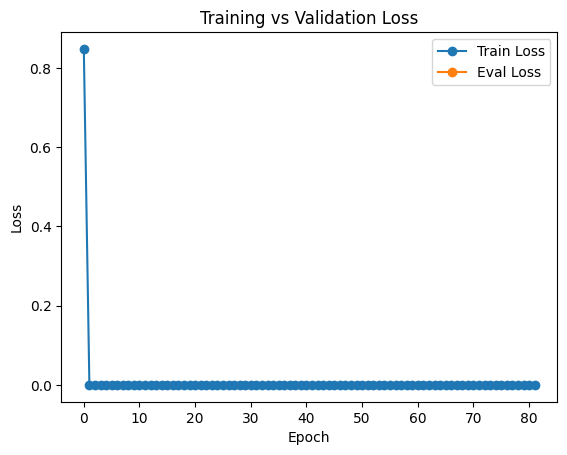

In [38]:
import matplotlib.pyplot as plt

plt.plot(range(len(train_loss)), train_loss, marker='o', label='Train Loss')
plt.plot(range(len(eval_loss)), eval_loss, marker='o', label='Eval Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


visualizations to understand model’s behavior

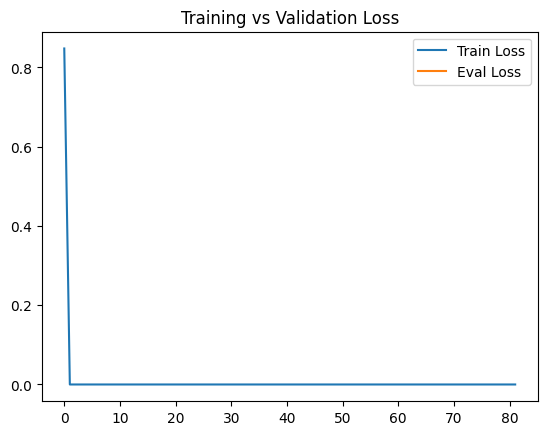

In [39]:
import matplotlib.pyplot as plt
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
plt.plot(train_loss, label='Train Loss')
plt.plot(eval_loss, label='Eval Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()


**Probability Distribution of dataset**

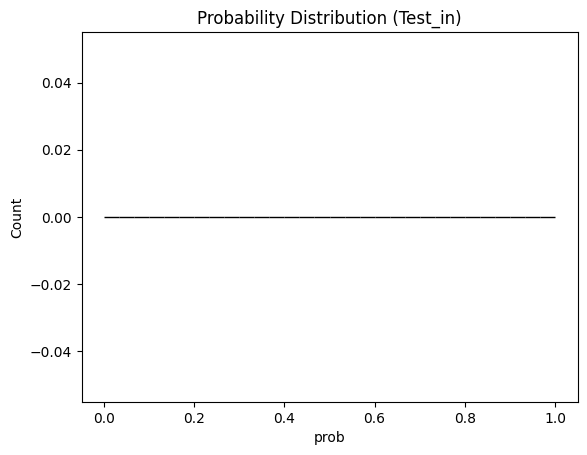

In [41]:
import pandas as pd
import seaborn as sns
df = pd.read_csv('/content/drive/MyDrive/results/stage1_probs_test_in.csv')
sns.histplot(df['prob'], bins=30, kde=True)
plt.title('Probability Distribution (Test_in)')
plt.show()


abhi model harama overfitted hai esko improve karlena koi bhi
